In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
df = pd.read_csv('/content/Fraud detection.csv')
df

,duration,protocal_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_same_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate_,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,9,1.0,0.0,0.11,0.00,0.00,0.00,0.0,0.0
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,19,1.0,0.0,0.05,0.00,0.00,0.00,0.0,0.0
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,29,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,39,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,49,1.0,0.0,0.02,0.00,0.00,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494016,0,tcp,http,SF,310,1881,0,0,0,0,...,86,255,1.0,0.0,0.01,0.05,0.00,0.01,0.0,0.0
494017,0,tcp,http,SF,282,2286,0,0,0,0,...,6,255,1.0,0.0,0.17,0.05,0.00,0.01,0.0,0.0
494018,0,tcp,http,SF,203,1200,0,0,0,0,...,16,255,1.0,0.0,0.06,0.05,0.06,0.01,0.0,0.0
494019,0,tcp,http,SF,291,1200,0,0,0,0,...,26,255,1.0,0.0,0.04,0.05,0.04,0.01,0.0,0.0


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 41 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494021 non-null  int64  
 1   protocal_type                494021 non-null  object 
 2   service                      494021 non-null  object 
 3   flag                         494021 non-null  object 
 4   src_bytes                    494021 non-null  int64  
 5   dst_bytes                    494021 non-null  int64  
 6   land                         494021 non-null  int64  
 7   wrong_fragment               494021 non-null  int64  
 8   urgent                       494021 non-null  int64  
 9   hot                          494021 non-null  int64  
 10  num_failed_logins            494021 non-null  int64  
 11  logged_in                    494021 non-null  int64  
 12  num_compromised              494021 non-null  int64  
 13 

In [78]:
df.isna().sum()

,0
duration,0
protocal_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [79]:
df.nunique()

,0
duration,2495
protocal_type,3
service,66
flag,11
src_bytes,3300
dst_bytes,10725
land,2
wrong_fragment,3
urgent,4
hot,22


In [80]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
le = LabelEncoder()

df_numeric = df.select_dtypes(exclude=['object'])
df_categorical = df.select_dtypes(include=['object'])

df_encoded = df_categorical.apply(le.fit_transform)
df = pd.concat([df_numeric, df_encoded], axis=1)

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)
df = pd.DataFrame(df_scaled, columns=df.columns)

In [81]:
df['count']

,count
0,0.015656
1,0.015656
2,0.015656
3,0.011742
4,0.011742
...,...
494016,0.007828
494017,0.011742
494018,0.011742
494019,0.011742


In [82]:
X = df.select_dtypes(include=[np.number])
X

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_diff_srv_rate_,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocal_type,service,flag
0,0.0,2.610418e-07,0.001057,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.11,0.00,0.00,0.00,0.0,0.0,0.5,0.338462,0.9
1,0.0,3.446905e-07,0.000094,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.05,0.00,0.00,0.00,0.0,0.0,0.5,0.338462,0.9
2,0.0,3.389216e-07,0.000259,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.03,0.00,0.00,0.00,0.0,0.0,0.5,0.338462,0.9
3,0.0,3.158461e-07,0.000259,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.03,0.00,0.00,0.00,0.0,0.0,0.5,0.338462,0.9
4,0.0,3.129617e-07,0.000394,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.02,0.00,0.00,0.00,0.0,0.0,0.5,0.338462,0.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494016,0.0,4.470881e-07,0.000365,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.01,0.05,0.00,0.01,0.0,0.0,0.5,0.338462,0.9
494017,0.0,4.067060e-07,0.000443,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.17,0.05,0.00,0.01,0.0,0.0,0.5,0.338462,0.9
494018,0.0,2.927706e-07,0.000233,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.06,0.05,0.06,0.01,0.0,0.0,0.5,0.338462,0.9
494019,0.0,4.196859e-07,0.000233,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.04,0.05,0.04,0.01,0.0,0.0,0.5,0.338462,0.9


In [83]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[0.00000000e+00, 2.61041764e-07, 1.05713002e-03, ...,
        5.00000000e-01, 3.38461538e-01, 9.00000000e-01],
       [0.00000000e+00, 3.44690506e-07, 9.42688423e-05, ...,
        5.00000000e-01, 3.38461538e-01, 9.00000000e-01],
       [0.00000000e+00, 3.38921627e-07, 2.59336301e-04, ...,
        5.00000000e-01, 3.38461538e-01, 9.00000000e-01],
       ...,
       [0.00000000e+00, 2.92770597e-07, 2.32762574e-04, ...,
        5.00000000e-01, 3.38461538e-01, 9.00000000e-01],
       [0.00000000e+00, 4.19685930e-07, 2.32762574e-04, ...,
        5.00000000e-01, 3.38461538e-01, 9.00000000e-01],
       [0.00000000e+00, 3.15846112e-07, 2.39357513e-04, ...,
        5.00000000e-01, 3.38461538e-01, 9.00000000e-01]])

In [84]:
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [85]:
input_dim = X_scaled.shape[1] #number of columns
input_layer = Input(shape=(input_dim,))

encoded = Dense(64, activation="relu")(input_layer)
encoded = Dense(32, activation="relu")(encoded)
bottleneck = Dense(16, activation="relu")(encoded)

decoded = Dense(32, activation="relu")(bottleneck)
decoded = Dense(64, activation="relu")(decoded)
output_layer = Dense(input_dim, activation="sigmoid")(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
opt = keras.optimizers.Adam(learning_rate=0.01)
autoencoder.compile(optimizer=opt, loss="mse")

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=5, min_lr=0.001)

In [95]:
history = autoencoder.fit(X_scaled, X_scaled,# both train and target value, because of unsupervised learning
                epochs=24,
                batch_size=1024,
                validation_split=0.1,
                callbacks=[reduce_lr],
                verbose=1)

Epoch 1/24
435/435 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 7.2117e-04 - val_loss: 0.0167 - learning_rate: 0.0010
Epoch 2/24
435/435 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 7.1946e-04 - val_loss: 0.0167 - learning_rate: 0.0010
Epoch 3/24
435/435 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 7.2754e-04 - val_loss: 0.0160 - learning_rate: 0.0010
Epoch 4/24
435/435 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 7.3609e-04 - val_loss: 0.0182 - learning_rate: 0.0010
Epoch 5/24
435/435 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 7.1835e-04 - val_loss: 0.0159 - learning_rate: 0.0010
Epoch 6/24
435/435 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 7.2677e-04 - val_loss: 0.0155 - learning_rate: 0.0010
Epoch 7/24
435/435 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.2972e-04 - val_loss: 0.0165 - learning_rate: 0.0010
Epoch 8/24
435/435 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7.1490e-04 - val_loss: 0.0172 - learning_rate: 0.0010
Epoch 9/24
435/435 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 7.3053e-04 - val_loss:

In [87]:
X_pred = autoencoder.predict(X_scaled)
mse = np.mean(np.power(X_scaled - X_pred, 2), axis=1)
df["reconstruction_error"] = mse

15439/15439 ━━━━━━━━━━━━━━━━━━━━ 21s 1ms/step


In [88]:
threshold = np.percentile(mse, 99)
df["is_anomaly"] = (mse > threshold).astype(int)

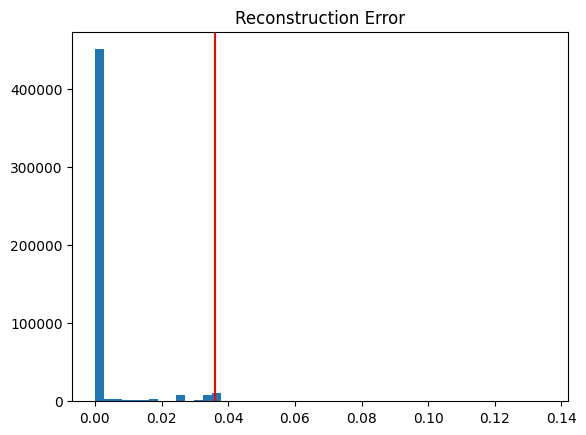

In [89]:
plt.hist(mse, bins=50)
plt.axvline(threshold, color='r')
plt.title("Reconstruction Error")
plt.show()


In [90]:
len(df[df.is_anomaly==1]) # with early stop = 4941

4940

In [92]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_true, df["is_anomaly"]))
print(classification_report(y_true, df["is_anomaly"]))

[[486449   2632]
 [  2632   2308]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    489081
           1       0.47      0.47      0.47      4940

    accuracy                           0.99    494021
   macro avg       0.73      0.73      0.73    494021
weighted avg       0.99      0.99      0.99    494021



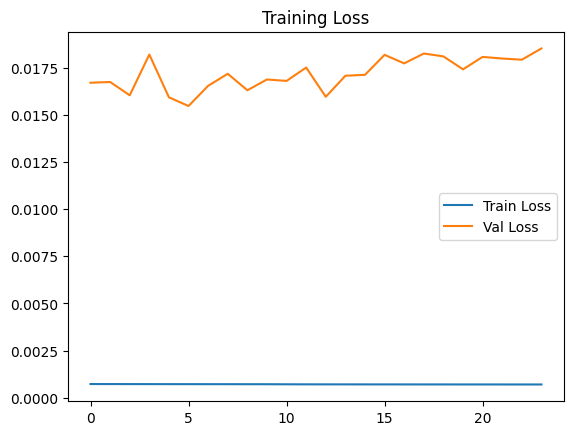

In [96]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Training Loss")
plt.show()


In [97]:
autoencoder.summary()
autoencoder.save("autoencoder_model.h5")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 41)             │         2,665 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,853 (124.43 KB)

 Trainable params: 10,617 (41.47 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,236 (82.96 KB)